# DOLFINx `.bp`, Tecplot `.szplt` and the vendor-runtime routes

Added in v16.13.0:

- **`vtx`** reads DOLFINx's `VTXWriter` output, an ADIOS2 `.bp` directory, as a time sequence. It needs a core built with ADIOS2, or the `adios2` Python package, and it matches ParaView's VTX reader.
- **`szplt`** reads Tecplot's SZL files through TecIO, the library Tecplot distributes, exactly as the same data saved as `.plt`.
- **Vendor-runtime routes** cover files only a vendor's software reads (Abaqus `.odb`, Marc `.t16`, Femap `.modfem`, Ansys results through PyDPF). Scripts under `contrib/` run in the vendor's own Python and write a series meshio++ reads; see `doc/vendor_routes.md`.

Every file below comes from `tests/python/meshes/`: real DOLFINx 0.11 runs, and TecIO-written SZL files.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# Keep the outputs readable: the warnings the readers and writers print are discussed in the text.
os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

MESHES = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'tests', 'python', 'meshes')
TMP = tempfile.mkdtemp()


def path(folder, name):
    return os.path.join(MESHES, folder, name)


def region_array(mesh, names=None):
    '''Per-cell index of the cell region holding each cell (NaN for none), as cell_data.'''
    regions = [r for r in mesh.regions if r.kind == 'cell' and (names is None or r.name in names)]
    flat = np.full(sum(len(c.data) for c in mesh.cells), np.nan)
    for k, r in enumerate(regions):
        flat[r.entries] = k
    out, start = [], 0
    for c in mesh.cells:
        out.append(flat[start:start + len(c.data)])
        start += len(c.data)
    return out


def curved(grid, level=3):
    '''The surface of `grid` with its quadratic cells subdivided, so curved edges look curved.'''
    return grid.extract_surface(nonlinear_subdivision=level, algorithm='dataset_surface')


def to_grid(mesh, cell_data=None, point_data=None, lines=False):
    '''A PyVista grid of `mesh`'s surfaces and solids (through a .vtu, so quadratic cells stay quadratic).'''
    keep = [i for i, c in enumerate(mesh.cells) if c.type not in ('vertex', 'line', 'line3', 'line4') or lines]
    cells = [mesh.cells[i] for i in keep]
    cd = {k: [v[i] for i in keep] for k, v in (cell_data or {}).items()}
    target = os.path.join(TMP, 'render.vtu')
    mp.write(target, mp.Mesh(mesh.points, cells, point_data=point_data or {}, cell_data=cd))
    return pv.read(target)


def gallery(items, ncols=2, size=(760, 460), view=(-1.0, -1.4, 0.45), edges=True, zoom=1.0):
    '''Render `(grid, scalars, title, clim)` items side by side, or with matplotlib when GL is unavailable.'''
    nrows = -(-len(items) // ncols)
    fig = plt.figure(figsize=(5.6 * ncols, 3.6 * nrows))
    for k, (grid, scalars, title, clim) in enumerate(items, start=1):
        try:
            pl = pv.Plotter(off_screen=True, window_size=size)
            pl.add_mesh(grid, scalars=scalars, cmap='turbo', clim=clim, show_edges=edges, edge_color='#333333',
                        line_width=0.6, nan_color='#bbbbbb',
                        scalar_bar_args={'title': scalars, 'vertical': True, 'position_x': 0.82,
                                         'position_y': 0.12, 'height': 0.76, 'width': 0.08})
            pl.view_vector(view, viewup=(0, 1, 0) if view == (0, 0, 1) else (0, 0, 1))
            pl.reset_camera()
            pl.camera.zoom(zoom)
            img = pl.screenshot(return_img=True)
            pl.close()
            ax = fig.add_subplot(nrows, ncols, k)
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            print('PyVista render skipped:', exc)
            ax = fig.add_subplot(nrows, ncols, k, projection='3d')
            p = np.asarray(grid.points)
            ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

from meshioplusplus import _core
print('ADIOS2 in the core:', _core.__has_adios2__, '| TecIO in the core:', _core.__has_tecio__)

ADIOS2 in the core: True | TecIO in the core: True


## A DOLFINx heat equation, step by step

`vtx/heat.bp` is DOLFINx's heat equation: P1 on triangles, backward Euler, three written steps. It uses `VTXMeshPolicy.reuse`, so only the first step holds the mesh; every step reads with it. DOLFINx writes P1 cells as VTK Lagrange triangles, which are read as plain `triangle`s.

times: [0.0, 0.01, 0.02]
[('triangle', 32)]


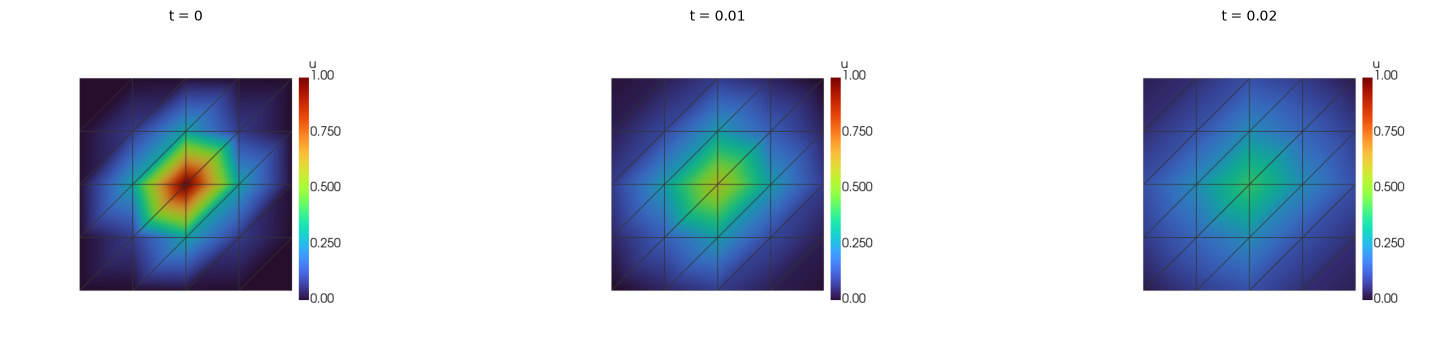

In [2]:
heat = path('vtx', 'heat.bp')
print('times:', mp.vtx.time_values(heat))
steps = list(mp.read_sequence(heat))
print([(c.type, len(c.data)) for c in steps[0][1].cells])
clim = (0.0, float(steps[0][1].point_data['u'].max()))
gallery([(to_grid(m, point_data={'u': m.point_data['u']}), 'u', f't = {t:g}', clim) for t, m in steps],
        ncols=3, size=(520, 460), view=(0, 0, 1))

## A P2 vector field and a DG0 field on tetrahedra

`vtx/elastic.bp` holds a P2 vector function (`displacement`) and a DG0 function (`density`) on tetrahedra, with the mesh rewritten every step (`VTXMeshPolicy.update`). Degree-2 VTK Lagrange tetrahedra read as `tetra10`, and DG0 functions are cell data.

[('tetra10', (24, 10))] [0.5]


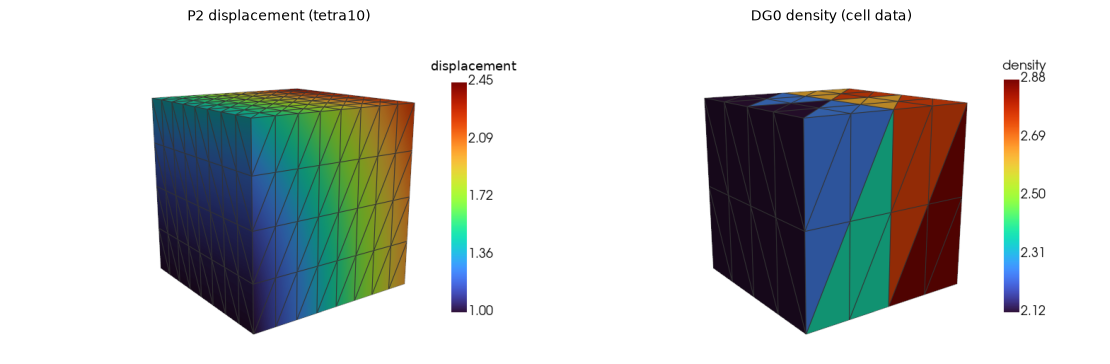

In [3]:
el = mp.read(path('vtx', 'elastic.bp'), time_step=-1)
print([(c.type, c.data.shape) for c in el.cells], el.field_data['meshio:time'])
grid = to_grid(el, point_data={'|displacement|': np.linalg.norm(el.point_data['displacement'], axis=1)},
               cell_data={'density': el.cell_data['density']})
gallery([(curved(grid, 2), '|displacement|', 'P2 displacement (tetra10)', None),
         (grid, 'density', 'DG0 density (cell data)', None)], ncols=2)

## A run on two MPI ranks

`vtx/heat_np2.bp` is the same heat run on two ranks. Every rank writes its own block, with its own point numbering and the ghost points it shares with the other rank. By default the blocks are concatenated as ParaView merges them. `ghosts="drop"` welds every ghost point onto its owner through `vtkOriginalPointIds`, which gives back the serial mesh.

points: ranks concatenated 38 | welded 25 | serial run 25


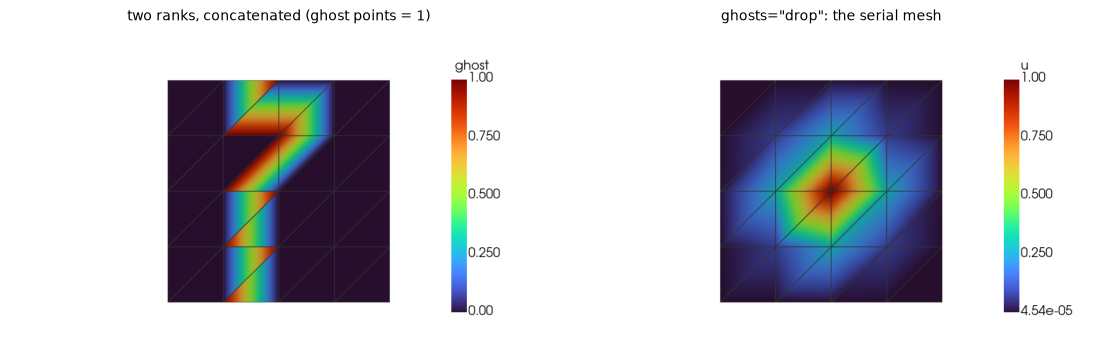

In [4]:
merged = mp.read(path('vtx', 'heat_np2.bp'))
welded = mp.vtx.read(path('vtx', 'heat_np2.bp'), ghosts='drop')
serial = mp.read(path('vtx', 'heat.bp'))
print('points: ranks concatenated', len(merged.points), '| welded', len(welded.points), '| serial run', len(serial.points))
gallery([(to_grid(merged, point_data={'ghost': merged.point_data['vtkGhostType'].astype(float)}), 'ghost',
          'two ranks, concatenated (ghost points = 1)', None),
         (to_grid(welded, point_data={'u': welded.point_data['u']}), 'u', 'ghosts="drop": the serial mesh', None)],
        ncols=2, view=(0, 0, 1))

## Tecplot SZL through TecIO

`szplt/transient.szplt` was written by TecIO. It holds three quad zones on one strand at t = 0, 0.5 and 1; the later zones share the first zone's coordinates and connectivity. With TecIO in the core, or a shared TecIO named by `MESHIOPLUSPLUS_TECIO_LIBRARY`, it reads as its ASCII twin `transient.dat` does. Without TecIO, the reader names what to install.

identical to the ASCII twin: True


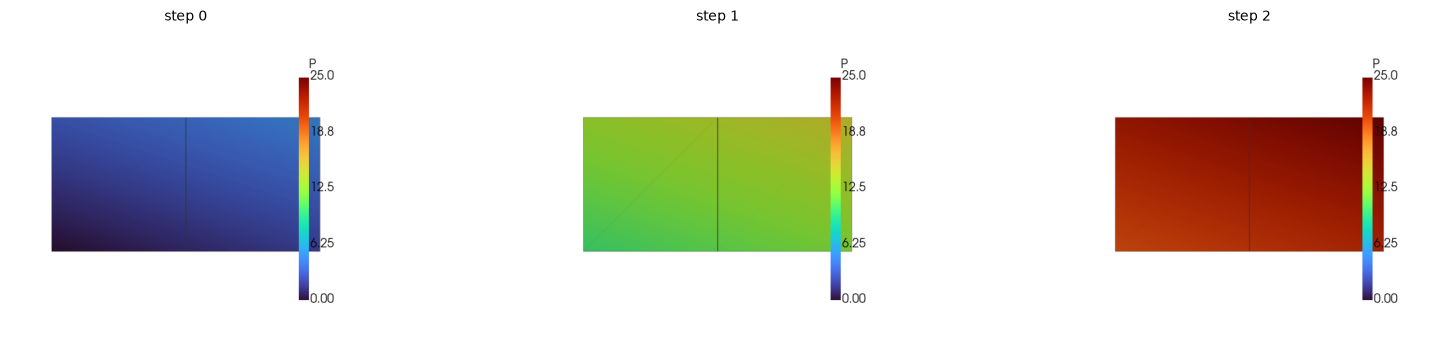

In [5]:
szl = path('szplt', 'transient.szplt')
try:
    frames = [mp.read(szl, time_step=k) for k in range(3)]
except ImportError as exc:
    print(exc)
else:
    twin = [mp.read(path('szplt', 'transient.dat'), time_step=k) for k in range(3)]
    print('identical to the ASCII twin:', all(np.array_equal(a.point_data['P'], b.point_data['P']) for a, b in zip(frames, twin)))
    gallery([(to_grid(m, point_data={'P': m.point_data['P']}), 'P', f'step {k}', (0, 25)) for k, m in enumerate(frames)],
            ncols=3, size=(520, 460), view=(0, 0, 1))

## What a vendor route writes

The scripts that run in a vendor's Python (`abaqus python`, Marc's PyPost) write through `contrib/common/mio_vtu_series.py`: a `.pvd` index with one `.vtu` per step and part, needing numpy only. Here the writer produces a two-part series by hand, the way the Abaqus exporter writes one part per instance. meshio++ reads it as a sequence, with one region per part.

0.0 ['PLATE-1', 'PLATE-2'] 8
1.0 ['PLATE-1', 'PLATE-2'] 8


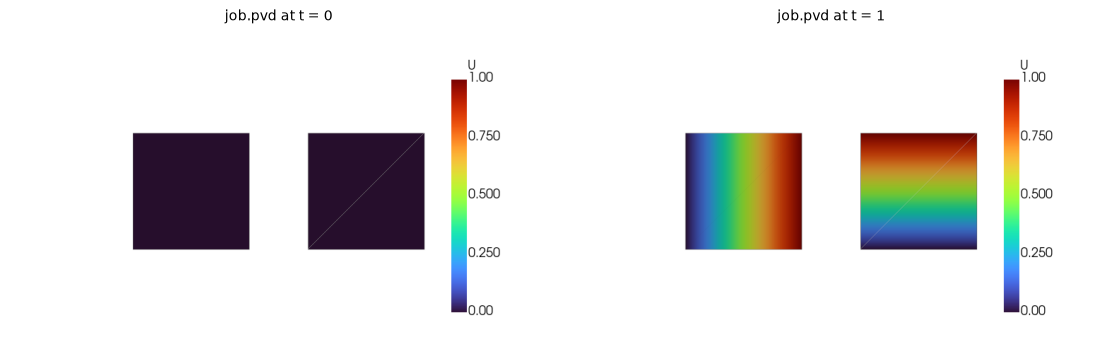

In [6]:
import importlib.util
spec = importlib.util.spec_from_file_location('mio_vtu_series', os.path.join(os.path.dirname(MESHES), '..', '..', 'contrib', 'common', 'mio_vtu_series.py'))
series_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(series_mod)
quad = np.array([[0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0]], float)
out = os.path.join(TMP, 'job.pvd')
with series_mod.PvdSeries(out) as series:
    for t in (0.0, 1.0):
        series.add(t, quad, [(9, [[0, 1, 2, 3]])], point_data={'U': quad[:, 0] * t}, part=0, name='PLATE-1')
        series.add(t, quad + [1.5, 0, 0], [(9, [[0, 1, 2, 3]])], point_data={'U': quad[:, 1] * t}, part=1, name='PLATE-2')
for t, m in mp.read_sequence(out):
    print(t, [r.name for r in m.regions], len(m.points))
gallery([(to_grid(m, point_data={'U': m.point_data['U']}), 'U', f'job.pvd at t = {t:g}', (0, 1))
         for t, m in mp.read_sequence(out)], ncols=2, view=(0, 0, 1))